# Imaging with AMI, part 1: simulating DISCO data from an image

Before reconstructing images from aperture-masking data, we need to be sure we can *simulate* such data from a known image. This tutorial does that for the JWST/NIRISS AMI observations processed by AMIGO, whose data products are "mixed DISCO" coefficients: linear projections of the log-amplitudes and phases of the complex visibilities.

We use the F480M record in `data/calibrated_visibility.npy`, the in-repo synthetic AMIGO-format record. It is a test stand-in whose 47 uv points lie on a line; real DISCO products sample a gridded uv half-plane, so this is *not* realistic AMI coverage. It is still useful here for its DISCO operators and error bars, and we replace its stored coefficients with a simulation. Everything below is simulated; the stored coefficients are never fitted or shown. The pixelised `Image` component and the truth scenes in `drpangloss.scenes` are new, and later parts of this series will fit images to data like these.

4.80 um, 47 uv points
longest baseline 9.2 m, finest fringes 108 mas


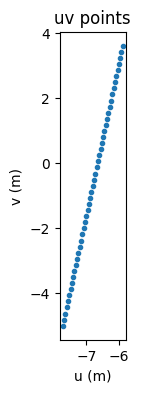

In [1]:
import sys
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from drpangloss._geometry import pixel_offsets
from drpangloss.amigo import load_oi_data
from drpangloss.models import BinaryModelCartesian, Image, PointSource, System
from drpangloss.plotting import plot_model
from drpangloss.scenes import ring, spiral

template = load_oi_data(repo_root / "data" / "calibrated_visibility.npy")[
    "F480M"
]
longest = float(jnp.hypot(template.u, template.v).max())
fringe_mas = 206265e3 * float(template.wavel) / longest
print(f"{1e6 * float(template.wavel):.2f} um, {template.u.size} uv points")
print(f"longest baseline {longest:.1f} m, finest fringes {fringe_mas:.0f} mas")

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(template.u, template.v, ".")
ax.set(xlabel="u (m)", ylabel="v (m)", title="uv points", aspect="equal")
plt.show()

All the points lie along one direction, so this record only constrains structure along that direction in the sky. That is fine for testing the machinery, but a fit to it would not recover a full image.

## The truth scene

At 4.8 µm the finest fringes have a period of about 100 mas, so structure on a few hundred milliarcseconds is well resolved, and pixels of 10 mas are fine enough. Our truth is a dusty spiral in the style of the "pinwheel" nebulae of WR 104 and WR 137, around an unresolved star.

`drpangloss.scenes.spiral` returns a unit-sum image in the drpangloss orientation (East left, North up). `Image.from_brightness` turns it into a model component whose pixels are the free parameters of an imaging fit. Like every component, it carries a `flux` relative to the others in a `System`. The stored errors of this record are tiny (around 3e-11), so we give the dust a contrast of 1000:1 relative to the star to get a signal-to-noise of order ten.

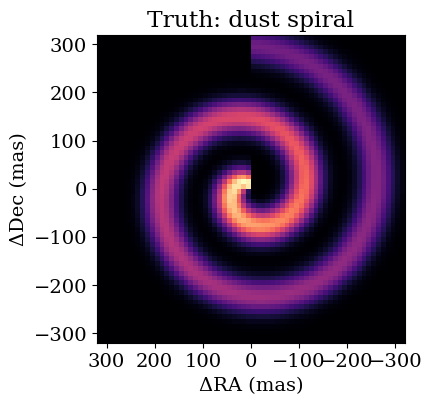

In [2]:
npix, pixel_scale = 64, 10.0  # 640 mas field of view
truth = spiral(
    npix,
    pixel_scale,
    step_mas=150.0,
    width_mas=25.0,
    turns=2.0,
    fade_mas=250.0,
)
scene = System(
    star=PointSource(),
    dust=Image.from_brightness(truth, pixel_scale, flux=1e-3),
)

plot_model(
    scene.dust,
    fov_mas=npix * pixel_scale,
    npix=npix,
    title="Truth: dust spiral",
)
plt.show()

## Simulating noisy data

`OIData.with_model` evaluates a model at the uv points of an existing data object, adds Gaussian noise with that object's error bars, and keeps the DISCO operators. The key makes the noise reproducible.

W0930 21:32:08.151379 9748727 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


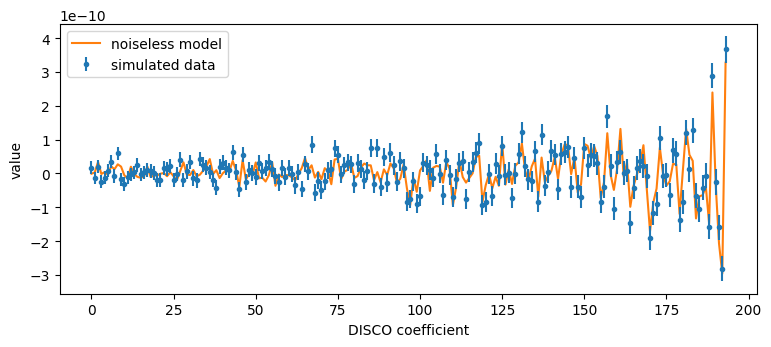

chi^2 of the truth: 244 for 194 coefficients


In [3]:
simulated = template.with_model(scene, key=jax.random.PRNGKey(0))
data, errors = simulated.flatten_data()
prediction = simulated.model(scene)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(prediction, "-", color="C1", label="noiseless model")
ax.errorbar(
    range(data.size), data, errors, fmt=".", color="C0", label="simulated data"
)
ax.set(xlabel="DISCO coefficient", ylabel="value")
ax.legend()
plt.show()

chi2 = jnp.sum(((data - prediction) / errors) ** 2)
print(f"chi^2 of the truth: {chi2:.0f} for {data.size} coefficients")

The first coefficients are projections of log-amplitudes and the rest of phases. The data scatter around the model within their error bars, and the chi-squared of the truth is comparable to the number of coefficients (it fluctuates by tens of percent between noise draws), as it should be.

## Check: one bright pixel is a binary

A good test of a pixelised model is a case with a known answer. An `Image` with all of its flux in a single pixel is a point source at that pixel's offset, so inside a `System` with a star it must agree with the analytic `BinaryModelCartesian`. Row 20 is North of the image centre and column 40 is West of it, so `pixel_offsets` gives the offset with East and North positive.

In [4]:
row, col = 20, 40
offsets = pixel_offsets(npix, pixel_scale)
one_pixel = jnp.full((npix, npix), -jnp.inf).at[row, col].set(0.0)

pixels = System(
    star=PointSource(), companion=Image(one_pixel, pixel_scale, flux=0.05)
)
binary = BinaryModelCartesian(dra=offsets[col], ddec=offsets[row], flux=0.05)

difference = jnp.abs(template.model(pixels) - template.model(binary))
print(
    f"companion at dRA = {offsets[col]:.0f} mas, dDec = {offsets[row]:.0f} mas"
)
print(f"largest difference in the DISCO observables: {difference.max():.1e}")
print(f"largest observable: {jnp.abs(template.model(binary)).max():.1e}")

companion at dRA = -85 mas, dDec = 115 mas
largest difference in the DISCO observables: 5.3e-15
largest observable: 2.1e-08


The two agree to float32 rounding, so the image and the analytic model are interchangeable in the likelihood.

## Another scene: a lopsided ring

`drpangloss.scenes` also has an inclined ring with one brighter side, and a Gaussian blob for clumps or companions. Position angles are measured from North towards East, so the brightest part of this ring, at position angle 90 degrees, lies to the left of the image.

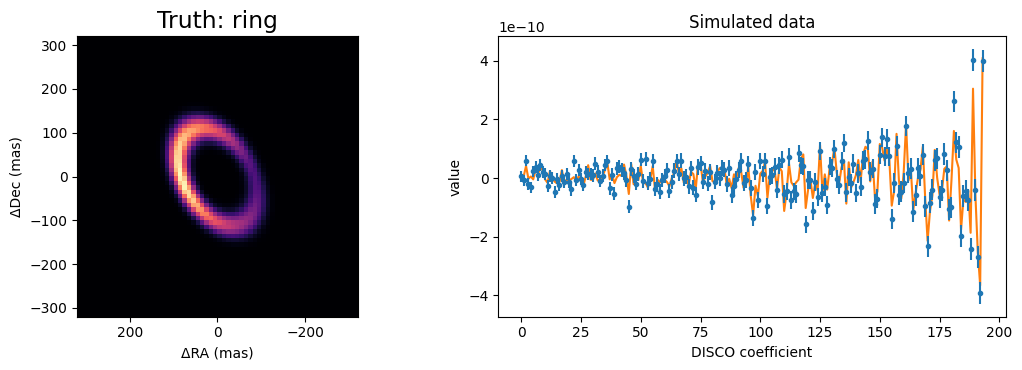

In [5]:
ring_image = ring(
    npix,
    pixel_scale,
    radius_mas=120.0,
    width_mas=20.0,
    inc_deg=50.0,
    pa_deg=30.0,
    asymmetry=0.6,
    asymmetry_pa_deg=90.0,
)
ring_scene = System(
    star=PointSource(),
    dust=Image.from_brightness(ring_image, pixel_scale, flux=1e-3),
)
ring_data = template.with_model(ring_scene, key=jax.random.PRNGKey(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
plot_model(
    ring_scene.dust,
    fov_mas=npix * pixel_scale,
    npix=npix,
    ax=axes[0],
    title="Truth: ring",
)
d, e = ring_data.flatten_data()
axes[1].plot(ring_data.model(ring_scene), "-", color="C1")
axes[1].errorbar(range(d.size), d, e, fmt=".", color="C0")
axes[1].set(xlabel="DISCO coefficient", ylabel="value", title="Simulated data")
plt.tight_layout()
plt.show()

## Next steps

We now have simulated data with the real AMI sampling and a truth to compare against. The next parts reconstruct the image from these data, starting from a parametric fit and moving to free pixels with regularisation.